In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, pickle
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [3]:
df_raw = pd.read_csv('heart_disease_uci.csv')
print('Full dataset shape:', df_raw.shape)
print('Datasets:', df_raw['dataset'].value_counts().to_dict())
df_raw.head(3)

Full dataset shape: (920, 16)
Datasets: {'Cleveland': 304, 'Hungary': 293, 'VA Long Beach': 200, 'Switzerland': 123}


,id,age,gender,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1


In [4]:
df = df_raw[df_raw['dataset'] == 'Cleveland'].copy().drop(columns=['id','dataset'])

# Encode categoricals
df['gender']     = (df['gender'] == 'Male').astype(int)
df['fbs']     = df['fbs'].map({True:1, False:0, 'True':1, 'False':0})
df['exang']   = df['exang'].map({True:1, False:0, 'True':1, 'False':0})
df['cp']      = df['cp'].map({'typical angina':0,'atypical angina':1,'non-anginal':2,'asymptomatic':3})
df['restecg'] = df['restecg'].map({'normal':0,'st-t abnormality':1,'lv hypertrophy':2})
df['slope']   = df['slope'].map({'upsloping':0,'flat':1,'downsloping':2})
df['thal']    = df['thal'].map({'normal':1,'fixed defect':2,'reversable defect':3})
df = df.rename(columns={'thalch':'thalach'})

# Binarise target: 0=no disease, 1=disease
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

print('Shape:', df.shape)
print('Target dist:', df['target'].value_counts().to_dict())
print('Nulls:', df.isnull().sum().to_dict())
df.head()

Shape: (304, 14)
Target dist: {0: 165, 1: 139}
Nulls: {'age': 0, 'gender': 0, 'cp': 0, 'trestbps': 0, 'chol': 0, 'fbs': 0, 'restecg': 0, 'thalach': 0, 'exang': 0, 'oldpeak': 0, 'slope': 1, 'ca': 5, 'thal': 3, 'target': 0}


,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145.0,233.0,1,2,150.0,0,2.3,2.0,0.0,2.0,0
1,67,1,3,160.0,286.0,0,2,108.0,1,1.5,1.0,3.0,1.0,1
2,67,1,3,120.0,229.0,0,2,129.0,1,2.6,1.0,2.0,3.0,1
3,37,1,2,130.0,250.0,0,0,187.0,0,3.5,2.0,0.0,1.0,0
4,41,0,1,130.0,204.0,0,2,172.0,0,1.4,0.0,0.0,1.0,0


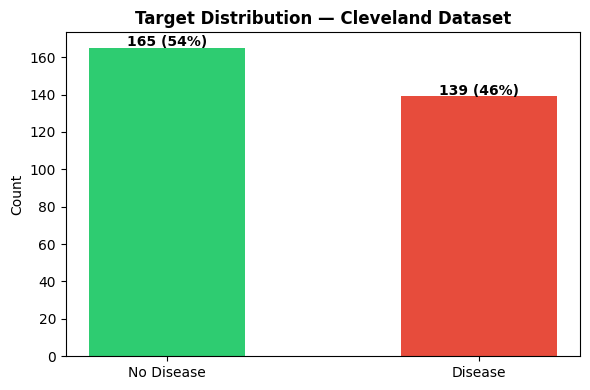

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df['target'].value_counts().sort_index()
ax.bar(['No Disease','Disease'], counts.values, color=['#2ecc71','#e74c3c'], width=0.5)
for i,(v) in enumerate(counts.values):
    ax.text(i, v+1, f'{v} ({v/len(df)*100:.0f}%)', ha='center', fontweight='bold')
ax.set_title('Target Distribution — Cleveland Dataset', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout(); 
plt.show();

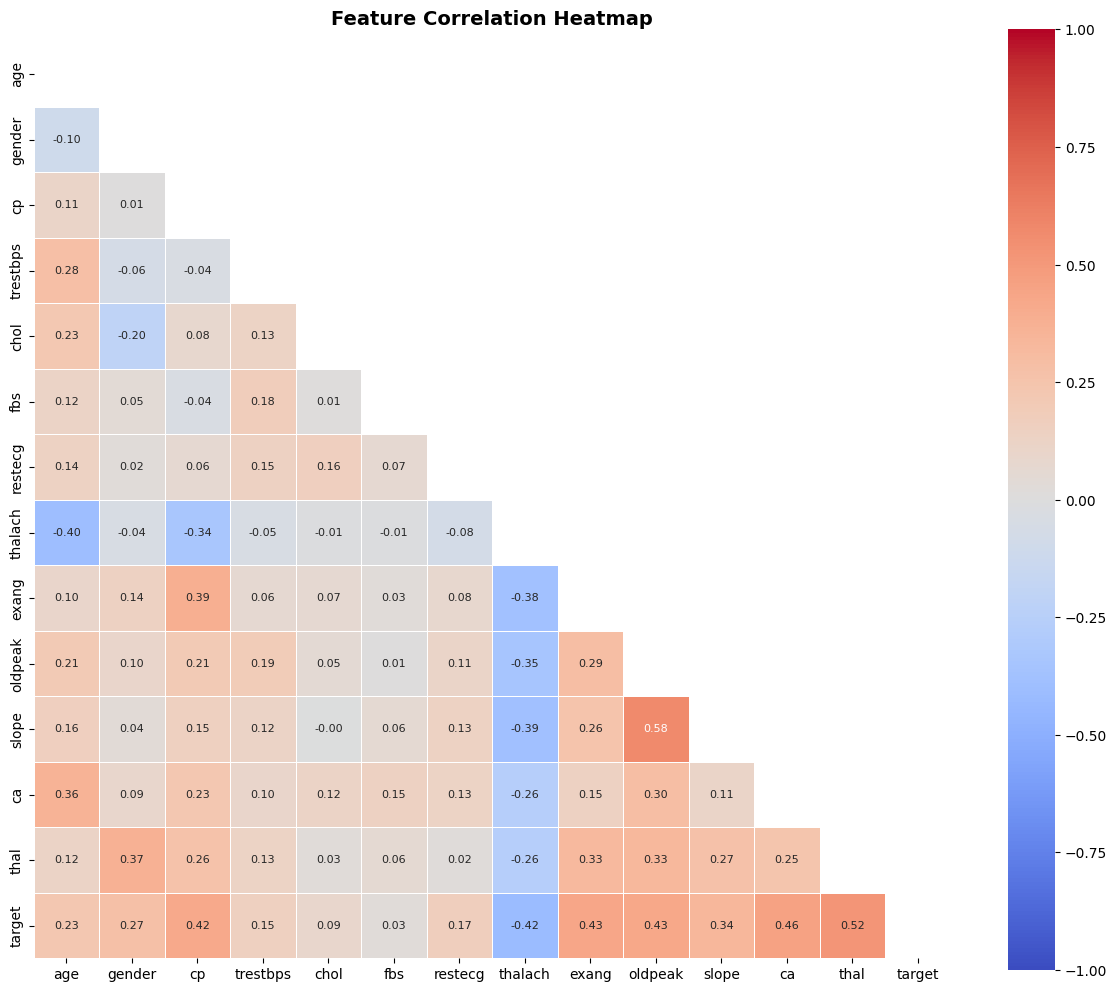

In [8]:
fig, ax = plt.subplots(figsize=(12,10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.4, ax=ax, annot_kws={'size':8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout(); plt.savefig('correlation_heatmap.png', bbox_inches='tight'); plt.show()

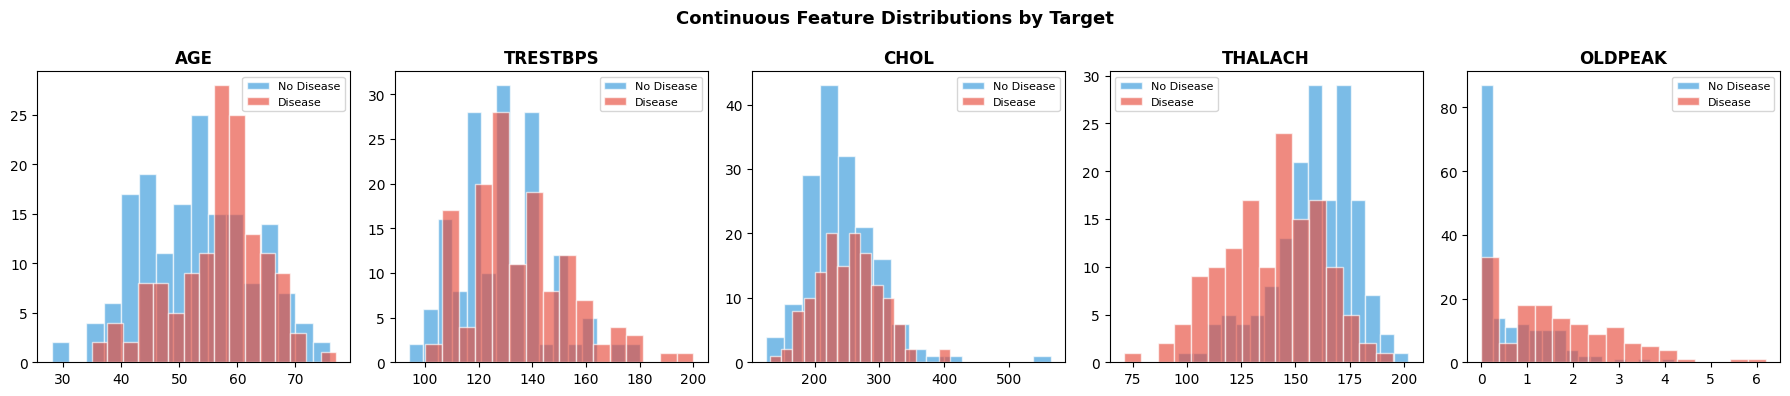

In [9]:
cont = ['age','trestbps','chol','thalach','oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18,4))
for ax, feat in zip(axes, cont):
    for cls, color, lbl in [(0,'#3498db','No Disease'),(1,'#e74c3c','Disease')]:
        ax.hist(df[df['target']==cls][feat].dropna(), bins=16, alpha=0.65, color=color, label=lbl, edgecolor='white')
    ax.set_title(feat.upper(), fontweight='bold'); ax.legend(fontsize=8)
plt.suptitle('Continuous Feature Distributions by Target', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('feature_dists.png', bbox_inches='tight'); plt.show()

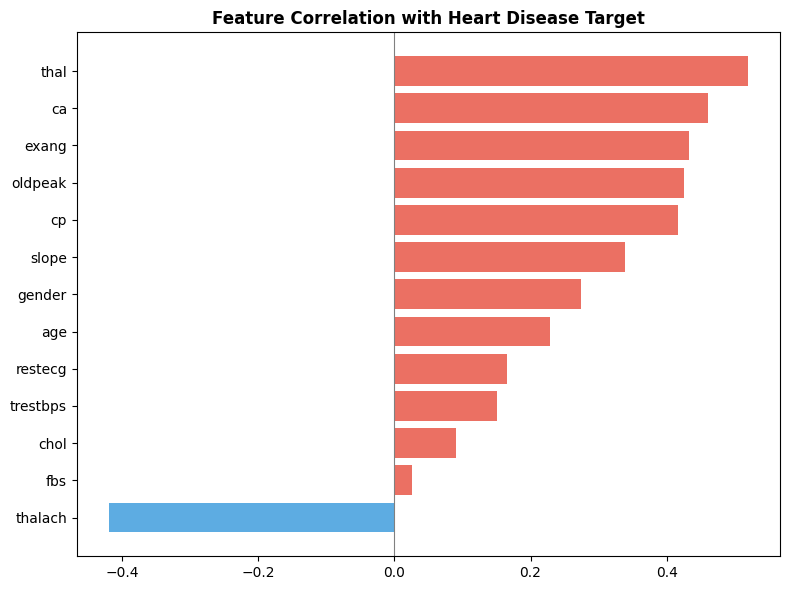

In [10]:
corr_t = df.corr()['target'].drop('target').sort_values()
fig, ax = plt.subplots(figsize=(8,6))
colors = ['#e74c3c' if v>0 else '#3498db' for v in corr_t.values]
ax.barh(corr_t.index, corr_t.values, color=colors, alpha=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Feature Correlation with Heart Disease Target', fontweight='bold')
plt.tight_layout(); plt.savefig('target_correlation.png', bbox_inches='tight'); 
plt.show()

In [18]:
feat_cols = ['age','gender','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']
X = df[feat_cols]; y = df['target']

# Impute + scale
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feat_cols)

X_train, X_test, y_train, y_test = train_test_split(X_imp, y, test_size=0.2, random_state=42, stratify=y)
scale_cols = ['age','trestbps','chol','thalach','oldpeak']
scaler = StandardScaler()
X_train_s = X_train.copy(); X_test_s = X_test.copy()
X_train_s[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_s[scale_cols]  = scaler.transform(X_test[scale_cols])

for fname, obj in [('scaler.pkl',scaler),('imputer.pkl',imputer),('scaler_cols.pkl',scale_cols),('feature_names.pkl',feat_cols)]:
    pickle.dump(obj, open(f'models/{fname}','wb'))
X_train_s.to_csv('data/X_train.csv', index=False)
X_test_s.to_csv('data/X_test.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)
print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape} | Nulls: {X_train_s.isnull().sum().sum()}')
print('Phase 1 Complete ✓')

Train: (243, 13) | Test: (61, 13) | Nulls: 0
Phase 1 Complete ✓
